# Non-Uniform Azimuthal Poisson Solver: N vs. M Analysis & Disk Error Comparisons

$$
u(r, \theta) = r^2 \left(R^2 - r^2\right) \exp\!\left( - \left[ \frac{\sin((\theta - \theta_0)/2)}{\sigma} \right]^2 \right)
$$

This problem is strictly $2\pi$-periodic and smooth, featuring a localized wave with a small width parameter $\sigma \ll 1$ and homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.paper.helpers import (
    get_azimuthal_gaussian_ridge_problem,
    run_all_algorithms_NxM_study,
    plot_solution_and_grids,
    plot_accuracy_faceted_by_method,
    plot_accuracy_from_df,
    plot_3x3_disk_error_comparison,
    plot_adapted_vs_highres_uniform,
    render_combined_error_table,
    render_combined_runtime_table,
    plot_extreme_runtime_2x2,
)

c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [2]:
R = 1.0                      # Disk radius
SIGMA = 0.12                 # Width of the Gaussian ridge
THETA_0 = np.pi              # Center angle of ridge (moved to pi for symmetry)

# Solver & Radial Grid Settings
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann

# Stronger angular clustering to resolve the thin layer
CLUSTER_STRENGTH = 0.5      # Increased clustering to capture the sharp ridge

# N vs M Sweep Grids
N_VALUES = [16, 32, 64, 128]
M_VALUES = [16, 32, 64, 128]

# High-Resolution Uniform Comparison Settings
N_LOW_ADAPT = 32
N_HIGH_UNIFORM = 128         # Cranked up to show Uniform FFT needs way more nodes
M_FIXED_PLOTS = 64

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

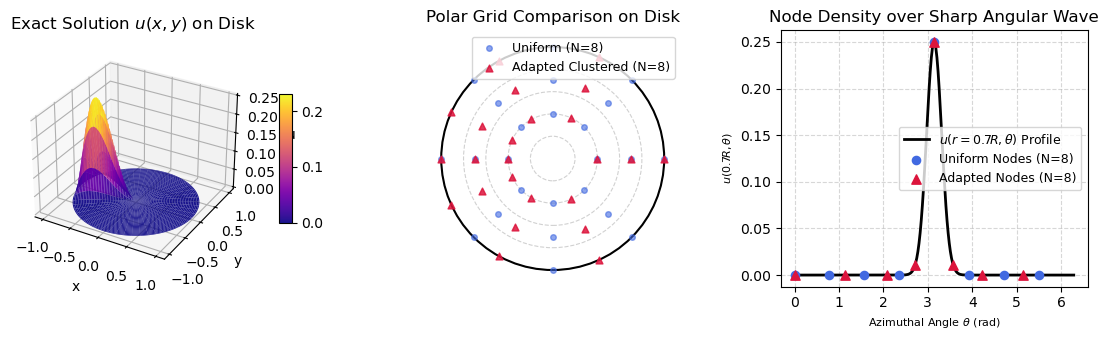

In [3]:
# Construct benchmark problem (Chebyshev boundary layer)
problem = get_azimuthal_gaussian_ridge_problem(
    R=R, theta_0=THETA_0, sigma=SIGMA
)

# Visualize 3D solution surface and 2D polar lattice
plot_solution_and_grids(
    problem=problem,
    N_adapt=8,
    N_unif=8,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,   # now 0.0
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [4]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
)

Computing N vs M Grid Matrix:   0%|          | 0/48 [00:00<?, ?it/s]

Computing N vs M Grid Matrix: 100%|██████████| 48/48 [00:08<00:00,  5.71it/s]


## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [5]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")


Relative L2 Error — N vs M, All Methods


## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

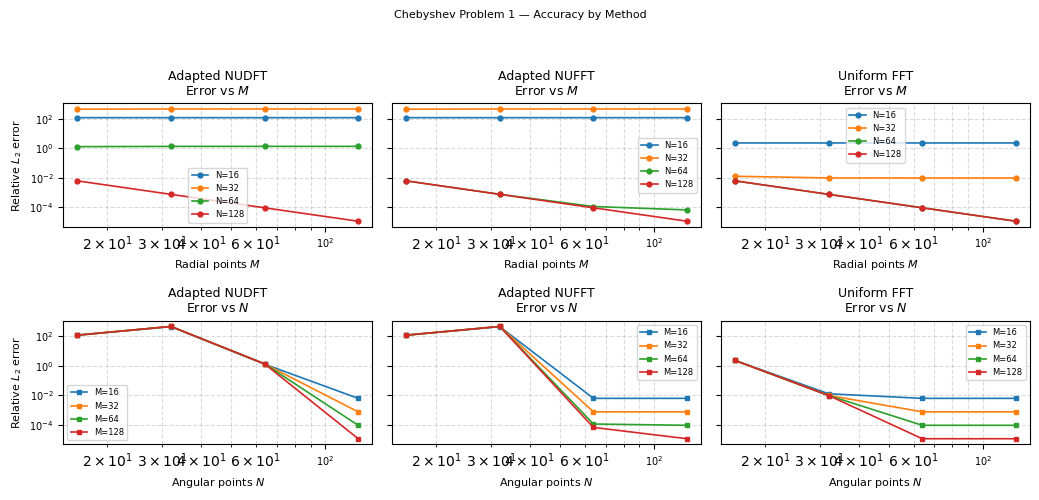

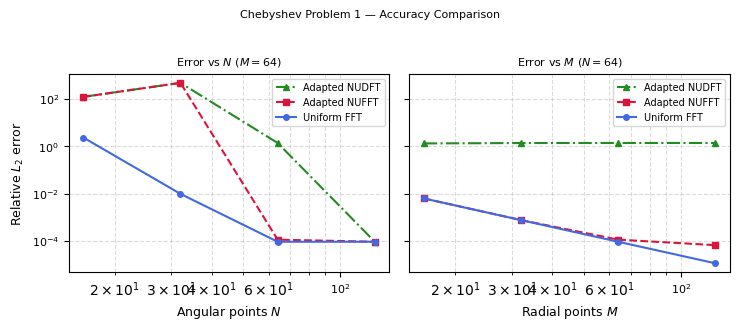

In [6]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 6. $3 \times 3$ Disk Error Comparison (Equal Resolution)
3D pointwise error surfaces on the disk at equal resolutions across:
- **Rows:** $N = 32, 64, 128$
- **Columns:** Adapted NUFFT | Adapted NUDFT | Uniform FFT

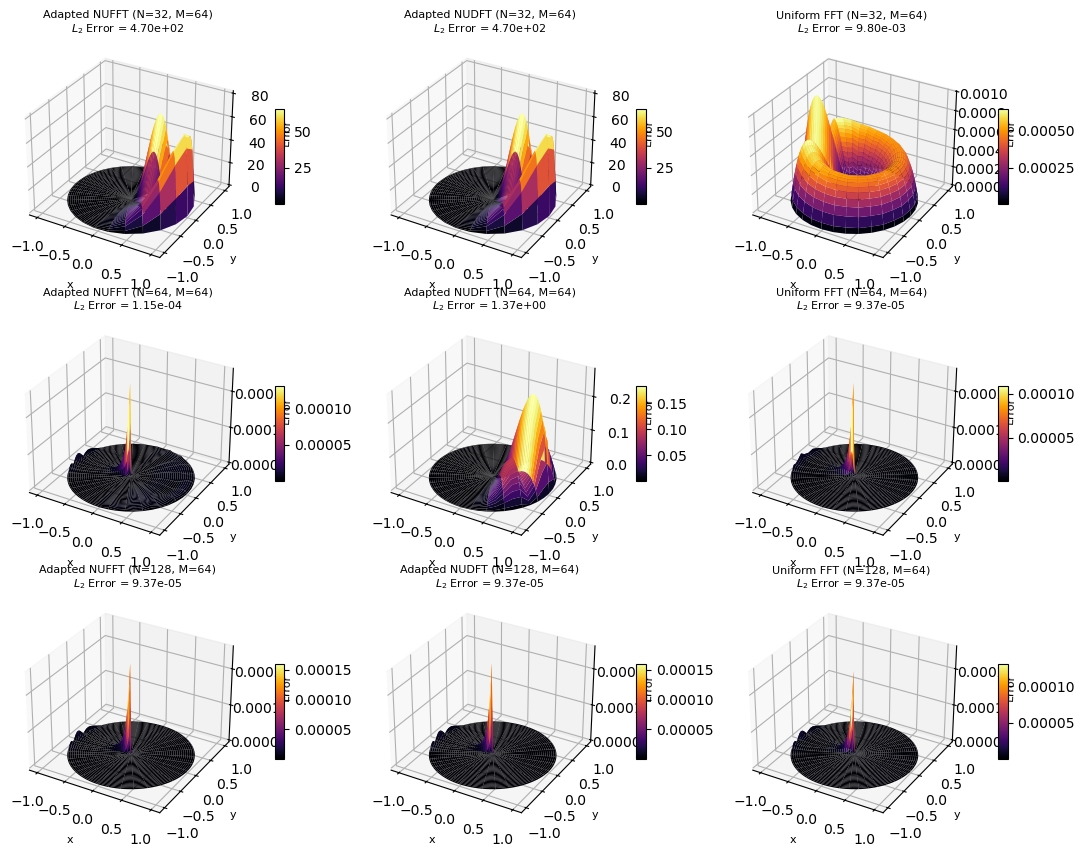

In [7]:
plot_3x3_disk_error_comparison(
    problem=problem,
    N_list=[32, 64, 128],
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).

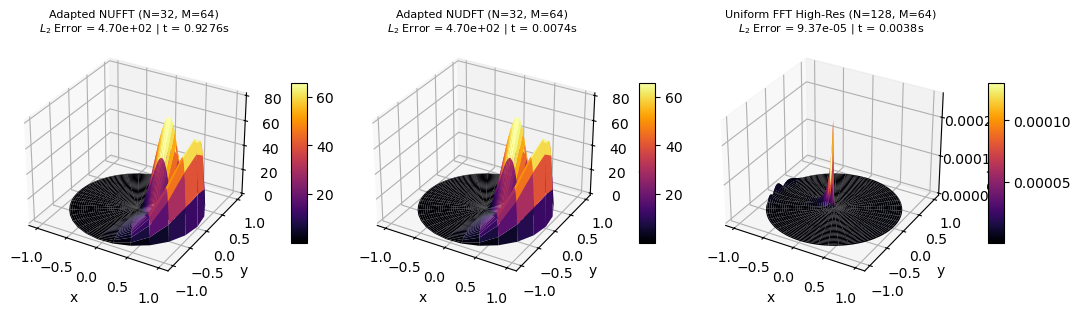

In [8]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

Runtime Tables ($N$ vs. $M$)



Combined Runtime Table — Methods × M (index N)


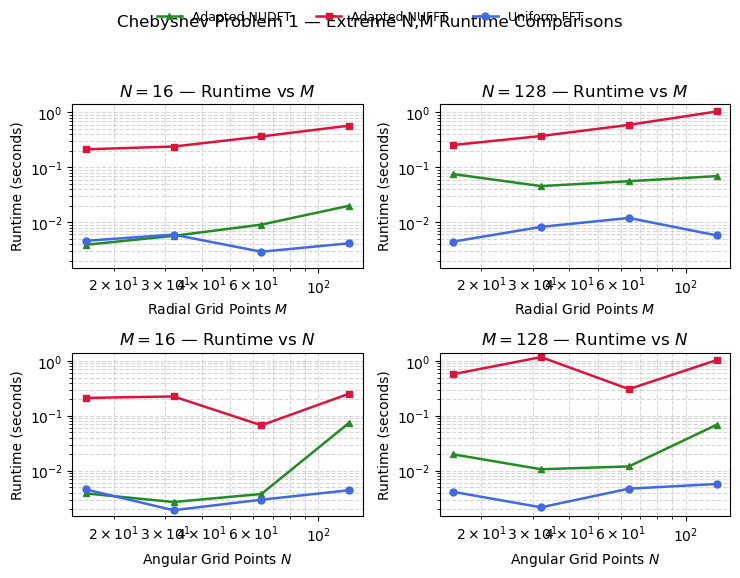

In [9]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results)